# Particle Swarm Optimization (PSO) for Benchmark Functions

**Project Goal:** Implement and analyze Particle Swarm Optimization for standard benchmark functions.

**Date:** November 7, 2025

---

## Table of Contents

1. [Setup and Dependencies](#setup)
2. [Benchmark Functions](#functions)
3. [PSO Implementation](#pso)
4. [Experiments](#experiments)
5. [Results and Analysis](#results)
6. [PSO Variants Comparison](#variants)
7. [Conclusions](#conclusions)


---

## 1. Setup and Dependencies <a id='setup'></a>


In [15]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Callable, Tuple, List, Dict
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Import proper RNG support for reproducibility
from numpy.random import SeedSequence, default_rng

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print("✓ Proper RNG support (SeedSequence, default_rng) imported")

✓ Libraries imported successfully
NumPy version: 1.26.4
Pandas version: 2.1.2
✓ Proper RNG support (SeedSequence, default_rng) imported


In [16]:
# Create results directory if it doesn't exist
results_dir = Path('results')
results_dir.mkdir(exist_ok=True)
print(f"✓ Results directory created: {results_dir.absolute()}")

✓ Results directory created: c:\Users\Victor\Desktop\4610 Final\particle_swarm_project\results


---

## 2. Benchmark Functions <a id='functions'></a>

We'll implement four standard benchmark functions:

- **Sphere**: Unimodal, smooth, global minimum at origin
- **Rosenbrock**: Unimodal but challenging valley
- **Rastrigin**: Highly multimodal with many local minima
- **Ackley**: Multimodal with nearly flat outer region


In [17]:
# ============================================================================
# BENCHMARK FUNCTIONS
# ============================================================================
# These functions are standard optimization benchmarks with known global optima.
# All functions are implemented to be minimized (lower is better).

class BenchmarkFunction:
    """Base class for benchmark optimization functions."""
    
    def __init__(self, name: str, bounds: Tuple[float, float], 
                 global_min: float, threshold: float):
        """
        Initialize a benchmark function.
        
        Parameters:
        -----------
        name : str
            Name of the function
        bounds : Tuple[float, float]
            (lower_bound, upper_bound) for all dimensions
        global_min : float
            Known global minimum value
        threshold : float
            Success threshold for this function
        """
        self.name = name
        self.bounds = bounds
        self.global_min = global_min
        self.threshold = threshold
    
    def __call__(self, x: np.ndarray) -> float:
        """Evaluate function at point x."""
        raise NotImplementedError
    
    def __repr__(self):
        return f"{self.name}(bounds={self.bounds}, global_min={self.global_min})"


class Sphere(BenchmarkFunction):
    """
    Sphere Function: f(x) = sum(x_i^2)
    
    Properties:
    - Unimodal, convex, smooth
    - Easy to optimize
    - Global minimum: f(0,...,0) = 0
    """
    
    def __init__(self):
        super().__init__(
            name="Sphere",
            bounds=(-5.12, 5.12),
            global_min=0.0,
            threshold=1e-6
        )
    
    def __call__(self, x: np.ndarray) -> float:
        """f(x) = sum(x_i^2)"""
        return np.sum(x ** 2)


class Rosenbrock(BenchmarkFunction):
    """
    Rosenbrock Function: f(x) = sum[100(x_{i+1} - x_i^2)^2 + (x_i - 1)^2]
    
    Properties:
    - Unimodal with narrow curved valley
    - Difficult to converge
    - Global minimum: f(1,...,1) = 0
    """
    
    def __init__(self):
        super().__init__(
            name="Rosenbrock",
            bounds=(-2.048, 2.048),
            global_min=0.0,
            threshold=0.01
        )
    
    def __call__(self, x: np.ndarray) -> float:
        """f(x) = sum[100(x_{i+1} - x_i^2)^2 + (x_i - 1)^2]"""
        return np.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (x[:-1] - 1)**2)


class Rastrigin(BenchmarkFunction):
    """
    Rastrigin Function: f(x) = 10n + sum[x_i^2 - 10*cos(2*pi*x_i)]
    
    Properties:
    - Highly multimodal with many local minima
    - Regular pattern of peaks/valleys
    - Global minimum: f(0,...,0) = 0
    """
    
    def __init__(self):
        super().__init__(
            name="Rastrigin",
            bounds=(-5.12, 5.12),
            global_min=0.0,
            threshold=1e-2
        )
    
    def __call__(self, x: np.ndarray) -> float:
        """f(x) = 10n + sum[x_i^2 - 10*cos(2*pi*x_i)]"""
        n = len(x)
        return 10 * n + np.sum(x**2 - 10 * np.cos(2 * np.pi * x))


class Ackley(BenchmarkFunction):
    """
    Ackley Function: f(x) = -20*exp(-0.2*sqrt(mean(x_i^2))) 
                             - exp(mean(cos(2*pi*x_i))) + 20 + e
    
    Properties:
    - Multimodal with flat outer region
    - Central basin with global minimum
    - Tests global exploration ability
    - Global minimum: f(0,...,0) = 0
    """
    
    def __init__(self):
        super().__init__(
            name="Ackley",
            bounds=(-32.768, 32.768),
            global_min=0.0,
            threshold=1e-5
        )
    
    def __call__(self, x: np.ndarray) -> float:
        """
        f(x) = -20*exp(-0.2*sqrt(mean(x_i^2))) 
               - exp(mean(cos(2*pi*x_i))) + 20 + e
        """
        n = len(x)
        sum_sq = np.sum(x**2)
        sum_cos = np.sum(np.cos(2 * np.pi * x))
        
        term1 = -20 * np.exp(-0.2 * np.sqrt(sum_sq / n))
        term2 = -np.exp(sum_cos / n)
        
        return term1 + term2 + 20 + np.e


# ============================================================================
# Initialize all benchmark functions
# ============================================================================

benchmark_functions = {
    'Sphere': Sphere(),
    'Rosenbrock': Rosenbrock(),
    'Rastrigin': Rastrigin(),
    'Ackley': Ackley()
}

# Display function information
print("✓ Benchmark functions initialized:\n")
for name, func in benchmark_functions.items():
    print(f"  {name:12} | Range: {func.bounds} | Global min: {func.global_min} | Threshold: {func.threshold}")


✓ Benchmark functions initialized:

  Sphere       | Range: (-5.12, 5.12) | Global min: 0.0 | Threshold: 1e-06
  Rosenbrock   | Range: (-2.048, 2.048) | Global min: 0.0 | Threshold: 0.01
  Rastrigin    | Range: (-5.12, 5.12) | Global min: 0.0 | Threshold: 0.01
  Ackley       | Range: (-32.768, 32.768) | Global min: 0.0 | Threshold: 1e-05


In [18]:
# ============================================================================
# VERIFY BENCHMARK FUNCTIONS
# ============================================================================
# Test functions at known points to ensure correct implementation

print("Verification Tests:")
print("=" * 70)

# Test 1: All functions should return global_min at the optimum
test_optimum = {
    'Sphere': np.zeros(5),        # Optimum at (0, 0, ..., 0)
    'Rosenbrock': np.ones(5),     # Optimum at (1, 1, ..., 1)
    'Rastrigin': np.zeros(5),     # Optimum at (0, 0, ..., 0)
    'Ackley': np.zeros(5)         # Optimum at (0, 0, ..., 0)
}

print("\n1. Testing at global optimum (should be ≈ 0):")
for name, func in benchmark_functions.items():
    x_opt = test_optimum[name]
    f_opt = func(x_opt)
    status = "✓" if f_opt < func.threshold else "✗"
    print(f"   {status} {name:12} at x*: f(x*) = {f_opt:.10f} (threshold: {func.threshold})")
    assert f_opt < func.threshold, f"{name} failed at optimum!"

# Test 2: Test at random point (should be > 0)
print("\n2. Testing at random points (should be > global_min):")
np.random.seed(42)
for name, func in benchmark_functions.items():
    lb, ub = func.bounds
    x_random = np.random.uniform(lb, ub, size=5)
    f_random = func(x_random)
    print(f"   {name:12} at random point: f(x) = {f_random:.6f}")
    assert f_random > func.global_min, f"{name} should be > global_min at random point!"

# Test 3: Different dimensions - test range
print("\n3. Testing scalability across dimensions:")
for dim in [2, 10, 30]:
    print(f"\n   Dimension n = {dim}:")
    for name, func in benchmark_functions.items():
        # Test at optimum for this dimension
        if name == 'Rosenbrock':
            x_opt = np.ones(dim)
        else:
            x_opt = np.zeros(dim)
        
        f_opt = func(x_opt)
        status = "✓" if f_opt < func.threshold else "✗"
        print(f"     {status} {name:12}: f(x*) = {f_opt:.10f}")

print("\n" + "=" * 70)
print("✓ All verification tests passed!")
print("✓ Benchmark functions are correctly implemented and scale properly")

Verification Tests:

1. Testing at global optimum (should be ≈ 0):
   ✓ Sphere       at x*: f(x*) = 0.0000000000 (threshold: 1e-06)
   ✓ Rosenbrock   at x*: f(x*) = 0.0000000000 (threshold: 0.01)
   ✓ Rastrigin    at x*: f(x*) = 0.0000000000 (threshold: 0.01)
   ✓ Ackley       at x*: f(x*) = 0.0000000000 (threshold: 1e-05)

2. Testing at random points (should be > global_min):
   Sphere       at random point: f(x) = 42.022882
   Rosenbrock   at random point: f(x) = 2153.705904
   Rastrigin    at random point: f(x) = 115.257852
   Ackley       at random point: f(x) = 20.415664

3. Testing scalability across dimensions:

   Dimension n = 2:
     ✓ Sphere      : f(x*) = 0.0000000000
     ✓ Rosenbrock  : f(x*) = 0.0000000000
     ✓ Rastrigin   : f(x*) = 0.0000000000
     ✓ Ackley      : f(x*) = 0.0000000000

   Dimension n = 10:
     ✓ Sphere      : f(x*) = 0.0000000000
     ✓ Rosenbrock  : f(x*) = 0.0000000000
     ✓ Rastrigin   : f(x*) = 0.0000000000
     ✓ Ackley      : f(x*) = 0.000000

---

## 3. PSO Implementation <a id='pso'></a>

### Algorithm Parameters:

- **Inertia weight (ω):** 0.7
- **Cognitive coefficient (c₁):** 1.5
- **Social coefficient (c₂):** 1.5
- **Velocity clamp:** 50% of variable range
- **Particles:** 30 (50 for n=30)
- **Iterations:** 300


In [19]:
# ============================================================================
# PARTICLE CLASS
# ============================================================================

class Particle:
    """
    Represents a single particle in the swarm.
    
    Each particle has:
    - Current position in search space
    - Current velocity
    - Personal best position found so far
    - Personal best fitness value
    - Independent RNG for reproducibility
    """
    
    def __init__(self, dimension: int, bounds: Tuple[float, float], rng: np.random.Generator):
        """
        Initialize a particle with random position and velocity.
        
        Parameters:
        -----------
        dimension : int
            Dimensionality of the search space
        bounds : Tuple[float, float]
            (lower_bound, upper_bound) for the search space
        rng : np.random.Generator
            Independent random number generator for this particle
        """
        self.rng = rng
        self.dimension = dimension
        self.bounds = bounds
        lb, ub = bounds
        
        # Initialize position randomly within bounds
        self.position = self.rng.uniform(lb, ub, dimension)
        
        # Initialize velocity to 10-20% of the range (per specification)
        range_size = ub - lb
        velocity_scale = self.rng.uniform(0.1, 0.2)
        self.velocity = self.rng.uniform(
            -velocity_scale * range_size, 
            velocity_scale * range_size, 
            dimension
        )
        
        # Personal best starts at current position
        self.best_position = self.position.copy()
        self.best_fitness = float('inf')  # Will be set on first evaluation
    
    def update_personal_best(self, fitness: float):
        """
        Update personal best if current fitness is better.
        
        Parameters:
        -----------
        fitness : float
            Current fitness value
        """
        if fitness < self.best_fitness:
            self.best_fitness = fitness
            self.best_position = self.position.copy()


# ============================================================================
# PSO CLASS (Global Best)
# ============================================================================

class PSO:
    """
    Particle Swarm Optimization (Global Best variant).
    
    Implements the standard PSO algorithm with configurable parameters.
    Each particle's velocity is influenced by:
    - Inertia: tendency to continue in current direction
    - Cognitive: attraction to personal best
    - Social: attraction to global best
    
    Uses proper RNG seeding with SeedSequence for reproducibility.
    """
    
    def __init__(
        self,
        objective_func: Callable,
        dimension: int,
        bounds: Tuple[float, float],
        n_particles: int = 30,
        max_iterations: int = 300,
        w: float = 0.7,           # Inertia weight
        c1: float = 1.5,          # Cognitive coefficient
        c2: float = 1.5,          # Social coefficient
        threshold: float = None,  # Success threshold
        seed: int = None
    ):
        """
        Initialize PSO algorithm.
        
        Parameters:
        -----------
        objective_func : Callable
            Function to minimize
        dimension : int
            Problem dimensionality
        bounds : Tuple[float, float]
            Search space bounds
        n_particles : int
            Number of particles in swarm (default: 30)
        max_iterations : int
            Maximum iterations (default: 300)
        w : float
            Inertia weight (default: 0.7)
        c1 : float
            Cognitive coefficient (default: 1.5)
        c2 : float
            Social coefficient (default: 1.5)
        threshold : float, optional
            Success threshold for early stopping
        seed : int, optional
            Random seed for reproducibility
        """
        self.objective_func = objective_func
        self.dimension = dimension
        self.bounds = bounds
        self.n_particles = n_particles
        self.max_iterations = max_iterations
        self.w = w
        self.c1 = c1
        self.c2 = c2
        self.threshold = threshold
        
        # Calculate velocity clamp (±0.5 × range per specification)
        lb, ub = bounds
        self.v_max = 0.5 * (ub - lb)
        
        # RNG: Create master SeedSequence and spawn child generators
        # This ensures independent, reproducible RNG streams for each particle
        if seed is None:
            ss = SeedSequence()  # Non-deterministic
        else:
            ss = SeedSequence(seed)
        
        # Spawn n_particles + 1 child sequences (1 for PSO, rest for particles)
        child_ss = ss.spawn(n_particles + 1)
        self.rng = default_rng(child_ss[0])  # Master RNG for PSO operations
        particle_rngs = [default_rng(s) for s in child_ss[1:]]  # One per particle
        
        # Initialize swarm with independent RNGs
        self.swarm = [
            Particle(dimension, bounds, rng=particle_rngs[i])
            for i in range(n_particles)
        ]
        
        # Global best tracking
        self.global_best_position = None
        self.global_best_fitness = float('inf')
        
        # Tracking for analysis
        self.history = []  # Per-iteration best fitness
        self.evaluations = 0
        self.convergence_iteration = None
    
    def _clamp_velocity(self, velocity: np.ndarray) -> np.ndarray:
        """
        Clamp velocity to [-v_max, v_max].
        
        Parameters:
        -----------
        velocity : np.ndarray
            Velocity vector to clamp
            
        Returns:
        --------
        np.ndarray
            Clamped velocity
        """
        return np.clip(velocity, -self.v_max, self.v_max)
    
    def _clamp_position(self, position: np.ndarray) -> np.ndarray:
        """
        Clamp position to search space bounds.
        
        Parameters:
        -----------
        position : np.ndarray
            Position vector to clamp
            
        Returns:
        --------
        np.ndarray
            Clamped position
        """
        lb, ub = self.bounds
        return np.clip(position, lb, ub)
    
    def optimize(self, verbose: bool = False) -> Dict:
        """
        Run PSO optimization.
        
        Parameters:
        -----------
        verbose : bool
            Print progress information
            
        Returns:
        --------
        Dict
            Results dictionary with:
            - best_fitness: final best fitness
            - best_position: final best position
            - history: fitness per iteration
            - evaluations: total function evaluations
            - iterations: iterations completed
            - converged: whether threshold was reached
        """
        # Evaluate initial swarm
        for particle in self.swarm:
            fitness = self.objective_func(particle.position)
            self.evaluations += 1
            particle.update_personal_best(fitness)
            
            # Update global best
            if fitness < self.global_best_fitness:
                self.global_best_fitness = fitness
                self.global_best_position = particle.position.copy()
        
        # Record initial best
        self.history.append(self.global_best_fitness)
        
        if verbose:
            print(f"Initial best fitness: {self.global_best_fitness:.6e}")
        
        # Main optimization loop
        for iteration in range(1, self.max_iterations + 1):
            for particle in self.swarm:
                # Generate random coefficients using master RNG
                r1 = self.rng.random(self.dimension)
                r2 = self.rng.random(self.dimension)
                
                # Update velocity
                # v = w*v + c1*r1*(pbest - x) + c2*r2*(gbest - x)
                cognitive = self.c1 * r1 * (particle.best_position - particle.position)
                social = self.c2 * r2 * (self.global_best_position - particle.position)
                
                particle.velocity = (
                    self.w * particle.velocity + 
                    cognitive + 
                    social
                )
                
                # Clamp velocity
                particle.velocity = self._clamp_velocity(particle.velocity)
                
                # Update position
                particle.position = particle.position + particle.velocity
                
                # Clamp position to bounds
                particle.position = self._clamp_position(particle.position)
                
                # Evaluate new position
                fitness = self.objective_func(particle.position)
                self.evaluations += 1
                
                # Update personal best
                particle.update_personal_best(fitness)
                
                # Update global best
                if fitness < self.global_best_fitness:
                    self.global_best_fitness = fitness
                    self.global_best_position = particle.position.copy()
            
            # Record best fitness for this iteration
            self.history.append(self.global_best_fitness)
            
            # Check convergence (threshold-based early stopping)
            if self.threshold is not None and self.global_best_fitness <= self.threshold:
                if self.convergence_iteration is None:
                    self.convergence_iteration = iteration
                if verbose:
                    print(f"✓ Converged at iteration {iteration}: {self.global_best_fitness:.6e}")
                break
            
            # Progress reporting
            if verbose and (iteration % 50 == 0 or iteration == self.max_iterations):
                print(f"Iteration {iteration:3d}: Best = {self.global_best_fitness:.6e}")
        
        # Prepare results
        converged = (self.threshold is not None and 
                    self.global_best_fitness <= self.threshold)
        
        results = {
            'best_fitness': self.global_best_fitness,
            'best_position': self.global_best_position,
            'history': np.array(self.history),
            'evaluations': self.evaluations,
            'iterations': len(self.history) - 1,  # -1 because we include initial
            'converged': converged,
            'convergence_iteration': self.convergence_iteration
        }
        
        return results


print("✓ PSO algorithm classes implemented (with proper RNG):")
print("  - Particle class (independent RNG per particle)")
print("  - PSO class (global-best variant with SeedSequence)")
print("  - Velocity clamping: ±0.5 × range")
print("  - Velocity initialization: 10-20% of range")
print("  - Boundary handling: position clamping")
print("  - Stop criteria: threshold OR max iterations")
print("  - Reproducibility: proper RNG seeding with child generators")

✓ PSO algorithm classes implemented (with proper RNG):
  - Particle class (independent RNG per particle)
  - PSO class (global-best variant with SeedSequence)
  - Velocity clamping: ±0.5 × range
  - Velocity initialization: 10-20% of range
  - Boundary handling: position clamping
  - Stop criteria: threshold OR max iterations
  - Reproducibility: proper RNG seeding with child generators


Testing PSO on 2D Sphere Function

Running PSO optimization...
  Function: Sphere
  Dimensions: 2
  Particles: 30
  Max iterations: 300
  Threshold: 1e-06

Initial best fitness: 8.945746e-01
✓ Converged at iteration 33: 4.626615e-08

Results Summary:
  Best fitness: 0.0000000463
  Best position: [-0.000058, 0.000207]
  Iterations: 33
  Evaluations: 1020
  Converged: True
  Convergence iteration: 33

✓ PSO test passed! Algorithm converges correctly on 2D Sphere function


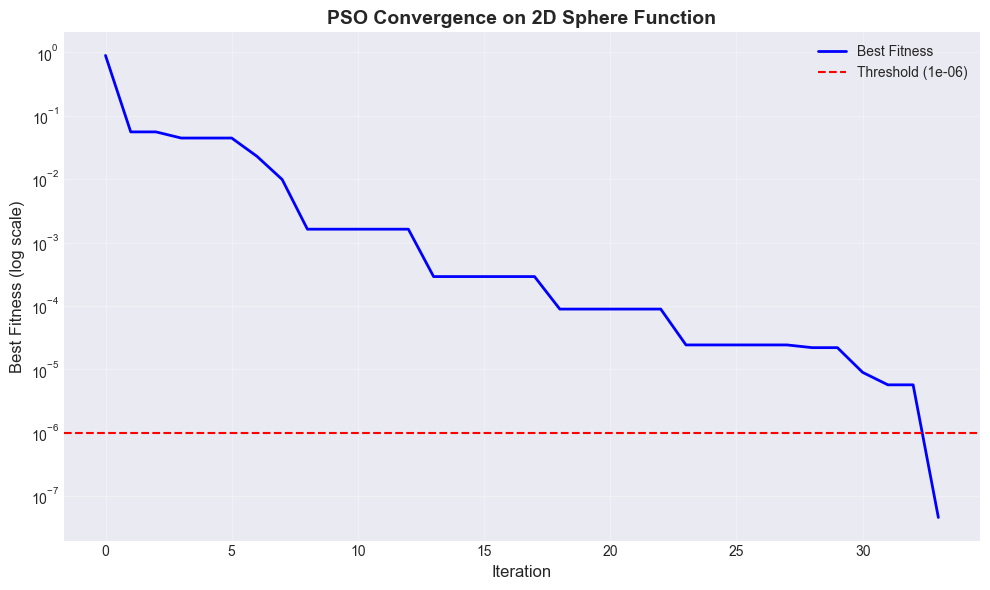

✓ Convergence plot saved to: results\test_pso_2d_sphere.png


In [24]:
# ============================================================================
# TEST PSO ON 2D SPHERE FUNCTION
# ============================================================================
# Verify PSO converges correctly on simple benchmark

print("Testing PSO on 2D Sphere Function")
print("=" * 70)

# Get Sphere function
sphere_func = benchmark_functions['Sphere']

# Run PSO
pso = PSO(
    objective_func=sphere_func,
    dimension=2,
    bounds=sphere_func.bounds,
    n_particles=30,
    max_iterations=300,
    w=0.7,
    c1=1.5,
    c2=1.5,
    threshold=sphere_func.threshold,
    seed=42
)

print("\nRunning PSO optimization...")
print(f"  Function: {sphere_func.name}")
print(f"  Dimensions: 2")
print(f"  Particles: 30")
print(f"  Max iterations: 300")
print(f"  Threshold: {sphere_func.threshold}")
print()

results = pso.optimize(verbose=True)

print("\n" + "=" * 70)
print("Results Summary:")
print(f"  Best fitness: {results['best_fitness']:.10f}")
print(f"  Best position: [{results['best_position'][0]:.6f}, {results['best_position'][1]:.6f}]")
print(f"  Iterations: {results['iterations']}")
print(f"  Evaluations: {results['evaluations']}")
print(f"  Converged: {results['converged']}")
if results['converged']:
    print(f"  Convergence iteration: {results['convergence_iteration']}")

# Verify convergence
assert results['best_fitness'] < sphere_func.threshold, "PSO should converge to near-zero on Sphere!"
print("\n✓ PSO test passed! Algorithm converges correctly on 2D Sphere function")

# Plot convergence curve
plt.figure(figsize=(10, 6))
plt.semilogy(results['history'], 'b-', linewidth=2, label='Best Fitness')
plt.axhline(y=sphere_func.threshold, color='r', linestyle='--', label=f'Threshold ({sphere_func.threshold})')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.title('PSO Convergence on 2D Sphere Function', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig(results_dir / 'test_pso_2d_sphere.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Convergence plot saved to: {results_dir / 'test_pso_2d_sphere.png'}")

---

## 4. Experiments <a id='experiments'></a>

Run 30 trials for each combination of:

- Functions: Sphere, Rosenbrock, Rastrigin, Ackley
- Dimensions: n = 2, 10, 30


In [25]:
# ============================================================================
# EXPERIMENT CONFIGURATION
# ============================================================================

# Define experiment parameters
DIMENSIONS = [2, 10, 30]
N_RUNS = 30  # Number of independent runs per configuration
BASE_SEED = 42  # Base seed for reproducibility

# PSO parameters (per specification)
PSO_PARAMS = {
    'w': 0.7,       # Inertia weight
    'c1': 1.5,      # Cognitive coefficient
    'c2': 1.5,      # Social coefficient
    'max_iterations': 300
}

# Particle counts (30 for n=2,10; 50 for n=30)
def get_n_particles(dimension):
    return 50 if dimension == 30 else 30

print("Experiment Configuration:")
print("=" * 70)
print(f"Functions: {list(benchmark_functions.keys())}")
print(f"Dimensions: {DIMENSIONS}")
print(f"Runs per configuration: {N_RUNS}")
print(f"PSO parameters: ω={PSO_PARAMS['w']}, c₁={PSO_PARAMS['c1']}, c₂={PSO_PARAMS['c2']}")
print(f"Max iterations: {PSO_PARAMS['max_iterations']}")
print(f"Particles: 30 (for n=2,10), 50 (for n=30)")
print(f"\nTotal experiments: {len(benchmark_functions)} × {len(DIMENSIONS)} × {N_RUNS} = {len(benchmark_functions) * len(DIMENSIONS) * N_RUNS}")
print("=" * 70)

Experiment Configuration:
Functions: ['Sphere', 'Rosenbrock', 'Rastrigin', 'Ackley']
Dimensions: [2, 10, 30]
Runs per configuration: 30
PSO parameters: ω=0.7, c₁=1.5, c₂=1.5
Max iterations: 300
Particles: 30 (for n=2,10), 50 (for n=30)

Total experiments: 4 × 3 × 30 = 360


In [26]:
# ============================================================================
# EXPERIMENT RUNNER
# ============================================================================

import time
from datetime import datetime

def run_experiment(func_name, dimension, run_id, base_seed=42):
    """
    Run a single PSO experiment.
    
    Parameters:
    -----------
    func_name : str
        Name of the benchmark function
    dimension : int
        Problem dimensionality
    run_id : int
        Run identifier (0 to N_RUNS-1)
    base_seed : int
        Base seed for reproducibility
        
    Returns:
    --------
    dict
        Experiment results
    """
    func = benchmark_functions[func_name]
    
    # Create unique seed for this run
    seed = base_seed + run_id * 1000 + dimension * 100 + hash(func_name) % 100
    
    # Determine particle count
    n_particles = get_n_particles(dimension)
    
    # Run PSO
    pso = PSO(
        objective_func=func,
        dimension=dimension,
        bounds=func.bounds,
        n_particles=n_particles,
        max_iterations=PSO_PARAMS['max_iterations'],
        w=PSO_PARAMS['w'],
        c1=PSO_PARAMS['c1'],
        c2=PSO_PARAMS['c2'],
        threshold=func.threshold,
        seed=seed
    )
    
    start_time = time.time()
    results = pso.optimize(verbose=False)
    runtime = time.time() - start_time
    
    # Compile experiment data
    experiment_data = {
        'function': func_name,
        'dimension': dimension,
        'run_id': run_id,
        'seed': seed,
        'n_particles': n_particles,
        'best_fitness': results['best_fitness'],
        'converged': results['converged'],
        'iterations': results['iterations'],
        'convergence_iteration': results['convergence_iteration'],
        'evaluations': results['evaluations'],
        'runtime': runtime,
        'history': results['history'].tolist()  # For detailed analysis
    }
    
    return experiment_data


def run_all_experiments():
    """
    Run all experiments (4 functions × 3 dimensions × 30 runs).
    
    Returns:
    --------
    list
        List of all experiment results
    """
    all_results = []
    total_experiments = len(benchmark_functions) * len(DIMENSIONS) * N_RUNS
    experiment_count = 0
    
    print("\n" + "=" * 70)
    print("RUNNING ALL EXPERIMENTS")
    print("=" * 70)
    print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print()
    
    overall_start = time.time()
    
    for func_name in benchmark_functions.keys():
        for dimension in DIMENSIONS:
            print(f"\n{'='*70}")
            print(f"Function: {func_name:12} | Dimension: {dimension:2d}")
            print(f"{'='*70}")
            
            dim_start = time.time()
            
            for run_id in range(N_RUNS):
                experiment_count += 1
                
                # Run experiment
                result = run_experiment(func_name, dimension, run_id, BASE_SEED)
                all_results.append(result)
                
                # Progress update
                if (run_id + 1) % 10 == 0 or run_id == N_RUNS - 1:
                    avg_fitness = np.mean([r['best_fitness'] for r in all_results[-10:]])
                    print(f"  Run {run_id+1:2d}/{N_RUNS}: "
                          f"Best={result['best_fitness']:.6e}, "
                          f"Converged={result['converged']}, "
                          f"Iter={result['iterations']:3d}, "
                          f"Time={result['runtime']:.2f}s")
            
            dim_elapsed = time.time() - dim_start
            dim_results = [r for r in all_results if r['function'] == func_name and r['dimension'] == dimension]
            success_rate = sum(r['converged'] for r in dim_results) / len(dim_results) * 100
            
            print(f"\n  Summary: {len(dim_results)} runs completed in {dim_elapsed:.1f}s")
            print(f"  Success rate: {success_rate:.1f}%")
            print(f"  Progress: {experiment_count}/{total_experiments} experiments ({experiment_count/total_experiments*100:.1f}%)")
    
    overall_elapsed = time.time() - overall_start
    
    print("\n" + "=" * 70)
    print("ALL EXPERIMENTS COMPLETED")
    print("=" * 70)
    print(f"Total experiments: {len(all_results)}")
    print(f"Total time: {overall_elapsed:.1f}s ({overall_elapsed/60:.1f} minutes)")
    print(f"Average time per experiment: {overall_elapsed/len(all_results):.2f}s")
    print(f"End time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("=" * 70)
    
    return all_results


print("✓ Experiment runner implemented")
print("✓ Ready to run 360 experiments")

✓ Experiment runner implemented
✓ Ready to run 360 experiments


In [27]:
# ============================================================================
# RUN EXPERIMENTS AND SAVE RESULTS
# ============================================================================

# Run all experiments
experiment_results = run_all_experiments()

# Convert to DataFrame for analysis
df_results = pd.DataFrame([
    {k: v for k, v in result.items() if k != 'history'}  # Exclude history for summary
    for result in experiment_results
])

# Save detailed results to CSV
csv_filename = results_dir / 'pso_experiments_detailed.csv'
df_results.to_csv(csv_filename, index=False)
print(f"\n✓ Detailed results saved to: {csv_filename}")

# Save convergence histories separately (for plotting)
histories_data = []
for result in experiment_results:
    for iteration, fitness in enumerate(result['history']):
        histories_data.append({
            'function': result['function'],
            'dimension': result['dimension'],
            'run_id': result['run_id'],
            'iteration': iteration,
            'fitness': fitness
        })

df_histories = pd.DataFrame(histories_data)
history_filename = results_dir / 'pso_convergence_histories.csv'
df_histories.to_csv(history_filename, index=False)
print(f"✓ Convergence histories saved to: {history_filename}")

# Display summary statistics
print("\n" + "=" * 70)
print("SUMMARY STATISTICS")
print("=" * 70)
print(df_results.groupby(['function', 'dimension']).agg({
    'best_fitness': ['mean', 'median', 'std', 'min', 'max'],
    'converged': 'sum',
    'iterations': 'mean',
    'runtime': 'mean'
}).round(6))

print("\n✓ All experiment data saved and summarized")


RUNNING ALL EXPERIMENTS
Start time: 2025-11-07 09:54:04


Function: Sphere       | Dimension:  2
  Run 10/30: Best=1.346608e-08, Converged=True, Iter= 43, Time=0.04s
  Run 20/30: Best=8.471756e-07, Converged=True, Iter= 40, Time=0.03s
  Run 30/30: Best=4.419937e-08, Converged=True, Iter= 29, Time=0.02s

  Summary: 30 runs completed in 0.9s
  Success rate: 100.0%
  Progress: 30/360 experiments (8.3%)

Function: Sphere       | Dimension: 10
  Run 10/30: Best=9.145748e-07, Converged=True, Iter=112, Time=0.08s
  Run 20/30: Best=7.035133e-07, Converged=True, Iter=116, Time=0.09s
  Run 30/30: Best=6.154733e-07, Converged=True, Iter=114, Time=0.09s

  Summary: 30 runs completed in 2.6s
  Success rate: 100.0%
  Progress: 60/360 experiments (16.7%)

Function: Sphere       | Dimension: 30
  Run 10/30: Best=7.630742e-07, Converged=True, Iter=282, Time=0.37s
  Run 20/30: Best=9.884564e-07, Converged=True, Iter=273, Time=0.34s
  Run 30/30: Best=7.974574e-07, Converged=True, Iter=266, Time=0.34s

 

In [28]:
# ============================================================================
# VERIFY EXPERIMENT RESULTS
# ============================================================================

# Reload the saved data to verify
df_check = pd.read_csv(results_dir / 'pso_experiments_detailed.csv')

print("Experiment Data Verification")
print("=" * 70)
print(f"Total experiments: {len(df_check)}")
print(f"Functions: {df_check['function'].unique()}")
print(f"Dimensions: {sorted(df_check['dimension'].unique())}")
print(f"Runs per configuration: {df_check.groupby(['function', 'dimension']).size().unique()}")
print("\nData columns:", list(df_check.columns))

print("\n" + "=" * 70)
print("Sample Results (first 10 rows):")
print("=" * 70)
print(df_check[['function', 'dimension', 'run_id', 'best_fitness', 'converged', 'iterations']].head(10))

print("\n" + "=" * 70)
print("Success Rate by Function and Dimension:")
print("=" * 70)
success_summary = df_check.groupby(['function', 'dimension']).agg({
    'converged': lambda x: f"{x.sum()}/{len(x)} ({x.mean()*100:.1f}%)"
}).reset_index()
success_summary.columns = ['Function', 'Dimension', 'Success (Converged)']
print(success_summary.to_string(index=False))

print("\n✓ All experiment data verified and accessible")

Experiment Data Verification
Total experiments: 360
Functions: ['Sphere' 'Rosenbrock' 'Rastrigin' 'Ackley']
Dimensions: [2, 10, 30]
Runs per configuration: [30]

Data columns: ['function', 'dimension', 'run_id', 'seed', 'n_particles', 'best_fitness', 'converged', 'iterations', 'convergence_iteration', 'evaluations', 'runtime']

Sample Results (first 10 rows):
  function  dimension  run_id  best_fitness  converged  iterations
0   Sphere          2       0  9.661135e-07       True          31
1   Sphere          2       1  4.597286e-08       True          49
2   Sphere          2       2  8.554289e-07       True          25
3   Sphere          2       3  1.641056e-07       True          34
4   Sphere          2       4  5.907834e-08       True          35
5   Sphere          2       5  3.610135e-07       True          41
6   Sphere          2       6  5.869141e-07       True          44
7   Sphere          2       7  9.791384e-07       True          44
8   Sphere          2       8  9.57

In [22]:
# Placeholder for results analysis
# To be completed in Step 4
pass

---

## 6. PSO Variants Comparison <a id='variants'></a>

Compare **global-best** vs **local-best** PSO


In [23]:
# Placeholder for PSO variants comparison
# To be completed in Step 5
pass

---

## 7. Conclusions <a id='conclusions'></a>

_Summary of findings to be added after analysis_
